# QHY268M Detector Characterization — 2026-07-17

Detector calibration/characteristic run, heavy clouds so only bias darks and twilight flats were taken.

# Bootstrap

In [2]:
# --- POLITE repo-root bootstrap ---
import os, sys
from pathlib import Path
_p = Path.cwd()
for _c in (_p, *_p.parents):
    if (_c / 'caltools').is_dir():
        os.chdir(_c); break
_r = str(Path.cwd())
if _r not in sys.path:
    sys.path.insert(0, _r)
print('root:', _r)

%load_ext autoreload
%autoreload 2

root: /Users/blu3/PycharmProjects/POLITE


In [3]:
import glob, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import caltools as ct
os.makedirs('tmpimg', exist_ok=True)

dir_prefix = "FITSDATA/20260717/"
subdir_prefixes = sorted([d for d in os.listdir(dir_prefix) if os.path.isdir(os.path.join(dir_prefix, d)) and d!='logs'])
dpi = 300

In [4]:
all_files = sorted(glob.glob(dir_prefix + '*/*.fits'))
all_file_groups = ct.group_by_type_and_exposure(all_files)

print(f"Total files: {len(all_files)}")
print("Subdirectories:", len(subdir_prefixes))

for subdir in subdir_prefixes:
    all_files = sorted(glob.glob(dir_prefix + subdir + '/*.fits'))
    file_groups = ct.group_by_type_and_exposure(all_files)
    print(f"\nSubdirectory: {subdir}")
    print(f"  Total files: {len(all_files)}")
    print("  File groups:")
    for (itype, exp), flist in sorted(file_groups.items()):
        print(f"    {itype:12s} {exp:8.3f}s  x{len(flist)}")

Total files: 204
Subdirectories: 5

Subdirectory: darkcal_T+0C_1932
  Total files: 40
  File groups:
    BIAS            0.000s  x25
    DARK            5.000s  x5
    DARK           60.000s  x5
    DARK          150.000s  x5

Subdirectory: darkcal_T-10C_2039
  Total files: 40
  File groups:
    BIAS            0.000s  x25
    DARK            5.000s  x5
    DARK           60.000s  x5
    DARK          150.000s  x5

Subdirectory: darkcal_T-14C_2110
  Total files: 40
  File groups:
    BIAS            0.000s  x25
    DARK            5.000s  x5
    DARK           60.000s  x5
    DARK          150.000s  x5

Subdirectory: ptc_twilight_T-15C_2015
  Total files: 42
  File groups:
    BIAS            0.000s  x12
    FLAT            0.100s  x4
    FLAT            0.200s  x4
    FLAT            0.500s  x4
    FLAT            1.000s  x4
    FLAT            2.000s  x4
    FLAT            4.000s  x6
    FLAT            8.000s  x4

Subdirectory: ptc_twilight_T-15C_2023
  Total files: 42
  File group

## Frame discovery

In [5]:
def grp(re):
    # func for globbing files that match a path regex
    return sorted(glob.glob(dir_prefix + re))

all_bias_files = grp('/*/*_Bias_*.fits')
main_bias_files = grp('/darkcal_T-14C*/*_Bias_*.fits')  # main bias files for master bias and read noise map

darkcal_files = {
    0.: ct.group_by_type_and_exposure(grp(subdir_prefixes[0] + '/*.fits')),
    -10.: ct.group_by_type_and_exposure(grp(subdir_prefixes[1] + '/*.fits')),
    -14.: ct.group_by_type_and_exposure(grp(subdir_prefixes[2] + '/*.fits')),
}

ptc_cover_files = ct.group_by_type_and_exposure(grp(subdir_prefixes[-2] + '/*.fits'))
ptc_open_files = ct.group_by_type_and_exposure(grp(subdir_prefixes[-1] + '/*.fits'))


print('Total bias frames:', len(all_bias_files))
for deg, grp in darkcal_files.items():
    print(f'Dark Cal run for {deg:+}C:')
    for (itype, exp), flist in sorted(darkcal_files[deg].items()):
        print(f"  {itype:12s} {exp:8.3f}s  x{len(flist)}")

print(f"PTC cover files:")
for (itype, exp), flist in sorted(ptc_cover_files.items()):
    print(f"   {itype:12s} {exp:8.3f}s  x{len(flist)}")

print(f"PTC open files:")
for (itype, exp), flist in sorted(ptc_open_files.items()):
    print(f"   {itype:12s} {exp:8.3f}s  x{len(flist)}")


sconfig = ct.sensor_config_from_header(main_bias_files[-1])
roi = (slice(0, 4210, None), slice(0, 6276, None))  # ROI removing overscan zeros
h0 = fits.getheader(main_bias_files[-1])
print(f"gain setting {h0.get('GAIN')}, offset {h0.get('OFFSET')}, "
      f"set {h0.get('SET-TEMP')}C, bias CMOS-TEMP {h0.get('CCD-TEMP')}C")

Total bias frames: 99
Dark Cal run for +0.0C:
  BIAS            0.000s  x25
  DARK            5.000s  x5
  DARK           60.000s  x5
  DARK          150.000s  x5
Dark Cal run for -10.0C:
  BIAS            0.000s  x25
  DARK            5.000s  x5
  DARK           60.000s  x5
  DARK          150.000s  x5
Dark Cal run for -14.0C:
  BIAS            0.000s  x25
  DARK            5.000s  x5
  DARK           60.000s  x5
  DARK          150.000s  x5
PTC cover files:
   BIAS            0.000s  x12
   FLAT            0.100s  x4
   FLAT            0.200s  x4
   FLAT            0.500s  x4
   FLAT            1.000s  x4
   FLAT            2.000s  x4
   FLAT            4.000s  x6
   FLAT            8.000s  x4
PTC open files:
   BIAS            0.000s  x12
   FLAT            0.100s  x4
   FLAT            0.200s  x4
   FLAT            0.500s  x4
   FLAT            1.000s  x4
   FLAT            2.000s  x4
   FLAT            4.000s  x6
   FLAT            8.000s  x4
gain setting 30, offset 50, set -14.0C

## Header Inspection

In [6]:
with fits.open(main_bias_files[-1]) as hdul:
    hdu = hdul[0]
    hdr = hdu.header
    display(hdr)

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                   16 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 6280                                                  
NAXIS2  =                 4210                                                  
EXPTIME =                  0.0 / Exposure time [s]                              
EXPOSURE=                  0.0 / Exposure time [s]                              
DATE-OBS= '2026-07-18T04:19:00.001' / Exposure start time                       
TIMESYS = 'UTC     '           / Time system                                    
TIMESRC = 'WIN-NTP '           / Timing source class                            
TIMEUNC =                  0.5 / 1-sigma timing uncertainty [s]                 
FWPOS   =                    4 / Filter-wheel slot index                        
FILTRDY = 'T       '        

## Frame inspection

Chosen file: FITSDATA/20260717/ptc_twilight_T-15C_2015/2026-07-17_FLAT_V_8s_004.fits


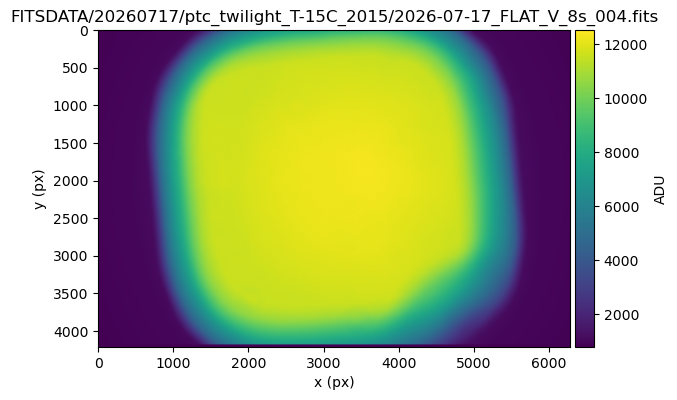

Average count: 7462.03


In [28]:
chosen_file = ptc_cover_files[('FLAT', 8.0)][-1]
print(f"Chosen file: {chosen_file}")
ct.quick_view(chosen_file)
print(f"Average count: {np.mean(fits.getdata(chosen_file)[roi]):.2f}")

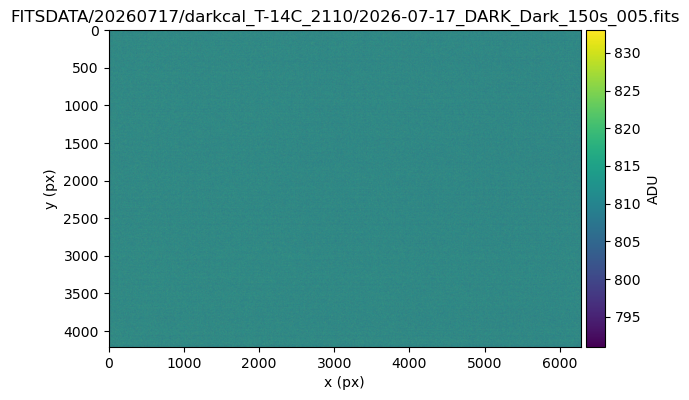

In [8]:
ct.quick_view(darkcal_files[-14][('DARK', 150.0)][-1])

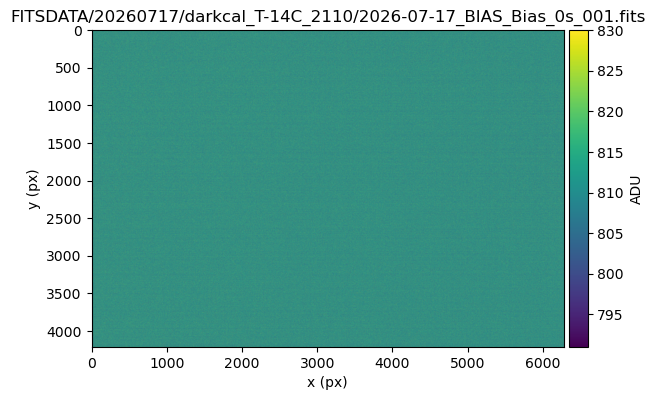

In [9]:
ct.quick_view(main_bias_files[0])

# 1. PTC

In [10]:
PTCDIR = dir_prefix + subdir_prefixes[-2]
ptc_file_groups = ct.group_by_type_and_exposure(sorted(glob.glob(PTCDIR + '/*.fits')))
ptc_bias_files = ptc_file_groups[('BIAS', 0.0)][:-2]   # exclude unity test
ptc_flat_files = {
    0.1: ptc_file_groups[('FLAT', 0.1)],
    0.2: ptc_file_groups[('FLAT', 0.2)],
    0.5: ptc_file_groups[('FLAT', 0.5)],
    1.0: ptc_file_groups[('FLAT', 1.0)],
    2.0: ptc_file_groups[('FLAT', 2.0)],
    4.0: ptc_file_groups[('FLAT', 4.0)][:-2],   # exclude unity test
    8.0: ptc_file_groups[('FLAT', 8.0)],
}
print(f"PTC bias files: {len(ptc_bias_files)}")
print("PTC flat files:")
for exp, flist in sorted(ptc_flat_files.items()):
    print(f"  {exp:6.2f}s  x{len(flist)}")

PTC bias files: 10
PTC flat files:
    0.10s  x4
    0.20s  x4
    0.50s  x4
    1.00s  x4
    2.00s  x4
    4.00s  x4
    8.00s  x4


## Bias

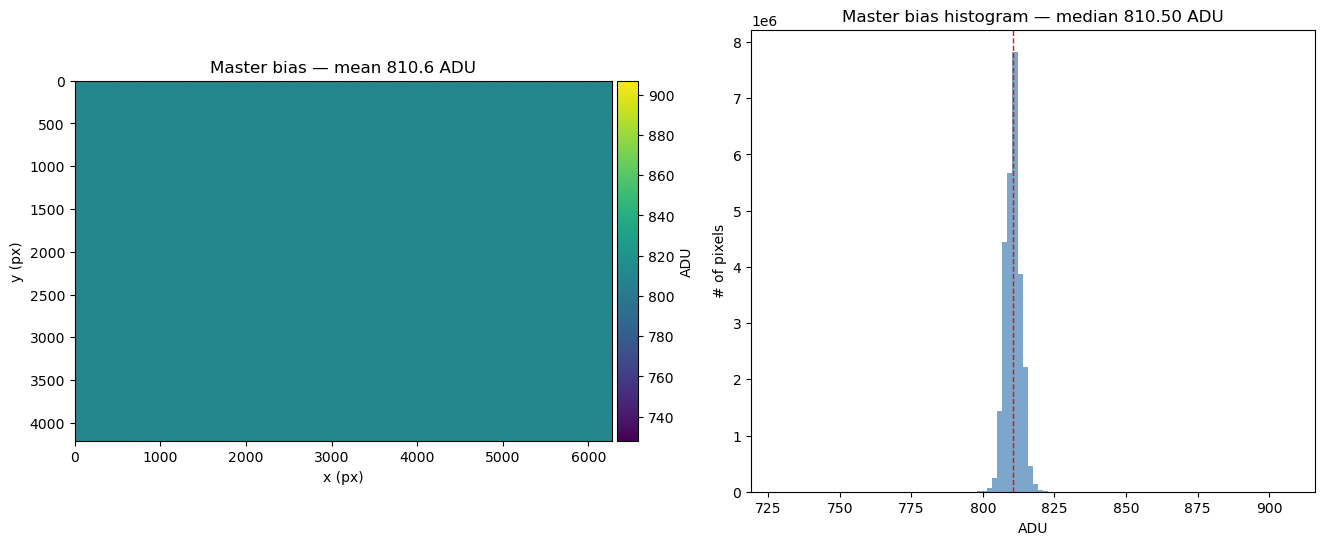

In [11]:
ptc_master_bias = ct.master_bias(ptc_bias_files, method='median', roi=roi)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ct.image_with_colorbar(axes[0], ptc_master_bias, label='ADU', percentile_clip=(0, 100))
axes[0].set_title(f'Master bias — mean {ptc_master_bias.mean():.1f} ADU')

axes[1].hist(ptc_master_bias.ravel(), bins=100, color='steelblue', alpha=0.7)
axes[1].set_xlabel('ADU'); axes[1].set_ylabel('# of pixels')
axes[1].set_title(f'Master bias histogram — median {np.median(ptc_master_bias):.2f} ADU')
axes[1].axvline(np.median(ptc_master_bias), ls='--', color='red', lw=1, label='median')
plt.show()

## MOMs and SDOMs Inspection of Flats

In [12]:
momsdom_result = ct.momsdom(ptc_flat_files, ptc_master_bias, roi=roi)
md = momsdom_result.metadata
exposures = md["exposures_s"]
moms = md["moms_adu"]
sdoms = md["sdoms_adu"]
mom_rates = md["mom_rates_adu_s"]
sdom_rates = md["sdom_rates_adu_s"]
ptc_mom_rows = md["mom_rows"]

In [13]:
print(" exposure    N       MOM (ADU)       SDOM (ADU)    MOM/exptime (ADU/s)")
for row in ptc_mom_rows:
    print(
        f" {row['exptime_s']:7.1f}  {row['n_frames']:3d}  "
        f"{row['mom_adu']:14.2f}  {row['sdom_adu']:15.2f}  "
        f"{row['mom_rate_adu_s']:19.2f}"
    )

 exposure    N       MOM (ADU)       SDOM (ADU)    MOM/exptime (ADU/s)
     0.1    4          140.49             1.07              1404.88
     0.2    4          268.14             2.10              1340.69
     0.5    4          635.37             5.36              1270.73
     1.0    4         1201.53            11.79              1201.53
     2.0    4         2243.17            27.64              1121.59
     4.0    4         4087.20            71.36              1021.80
     8.0    4         7105.67           197.89               888.21


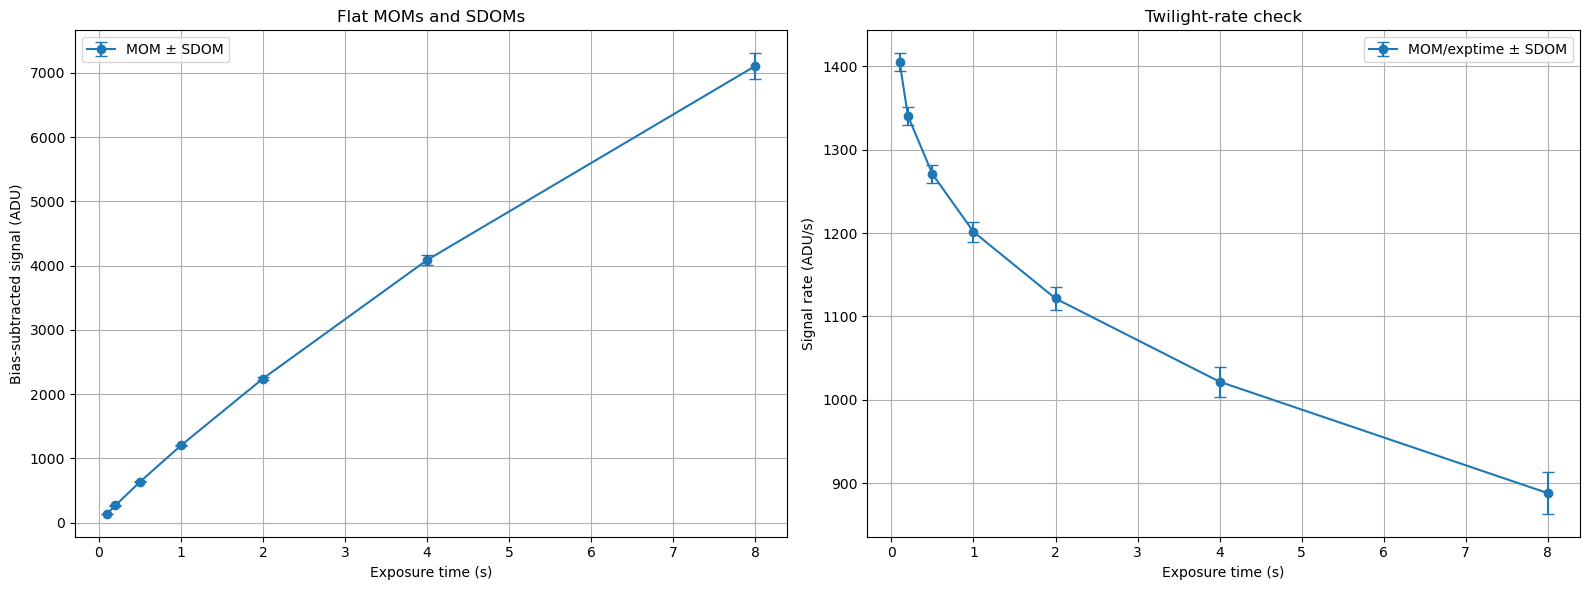

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ct.momsdom_twilight_plot(axes, momsdom_result, log_scale=False)
plt.savefig("tmpimg/0717_momsdom_twilight_plot.png"); plt.show()

## PTC Calculations/Plot

In [15]:
ptc_result = ct.photon_transfer_curve(ptc_flat_files, ptc_master_bias, roi=roi)

md = ptc_result.metadata
ss = ptc_result.scalar_summary

fit = md['fit']
signal = md['signal']
variance = md['variance']
labels = md['labels']
mismatch = md['mismatch']
ptc_pair_rows = md['pair_rows']
m, c, gain, sigma_g, cov = fit['slope'], fit['intercept'], fit['gain'], fit['gain_sigma'], fit['cov']
print(f"PTC fit: slope {m:.6f}, intercept {c:.3f}, gain {gain:.3f} e-/ADU, sigma_gain {sigma_g:.6f} e-/ADU")

ron_fit_adu = ss['ron_fit_adu']
signal_max_adu = ss['signal_max_adu']
print(f"RON fit (ADU): {ron_fit_adu:.3f} ADU, signal max (ADU): {signal_max_adu:.3f} ADU")
print(f"RON fit (e-): {ron_fit_adu * gain:.3f} e-")

PTC fit: slope 2.697987, intercept 33.096, gain 0.371 e-/ADU, sigma_gain 0.000016 e-/ADU
RON fit (ADU): 5.753 ADU, signal max (ADU): 7412.051 ADU
RON fit (e-): 2.132 e-


In [16]:
print(" exposure  pair   mean signal (ADU)  variance (ADU^2)  pair mismatch (%)")
for i, row in enumerate(ptc_pair_rows):
    print(
        f" {row['exptime_s']:7.1f}  {row['pair']:4d}  {row['signal_adu']:17.2f}  ",
        f"{row['variance_adu2']:17.2f}  {row['mismatch']:17.3f}"
    )

 exposure  pair   mean signal (ADU)  variance (ADU^2)  pair mismatch (%)
     0.1     3             142.15              450.72              1.143
     0.1     3             138.82              441.99              1.192
     0.2     3             271.39              765.05              1.205
     0.2     3             264.88              748.31              1.213
     0.5     3             643.67             1760.75              1.308
     0.5     3             627.06             1705.95              1.305
     1.0     3            1219.74             3284.77              1.545
     1.0     3            1183.33             3189.20              1.527
     2.0     3            2286.00             6239.93              1.895
     2.0     3            2200.34             5970.49              1.917
     4.0     3            4197.74            11355.37              2.695
     4.0     3            3976.66            10751.33              2.717
     8.0     3            7412.05            20038.

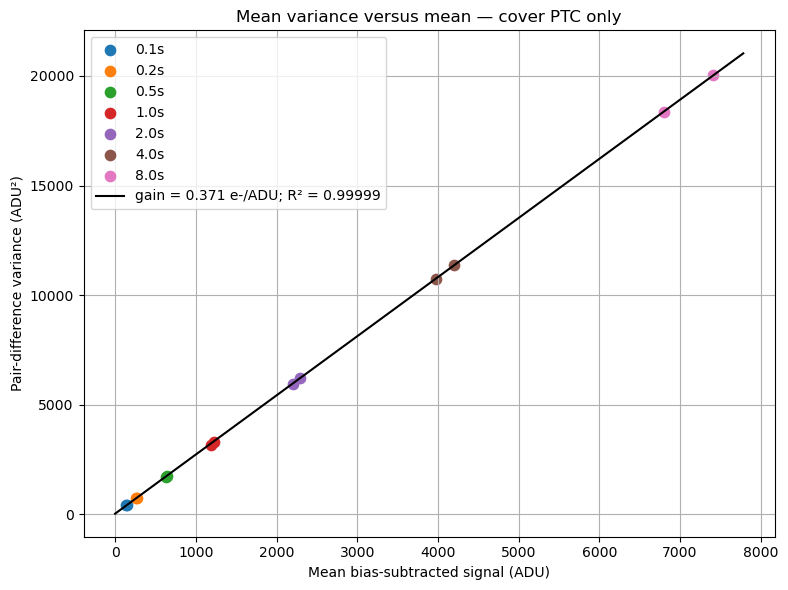

Maximum pair mismatch: 4.35%
PTC gain = 0.370647 ± 0.000016 e-/ADU (formal fit error)
PTC-intercept read noise = 5.753 ADU = 2.132 e-
Highest sampled pixel signal = 7412.1 ADU (2747 e- at this gain).


In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
ct.ptc_plot(ax, ptc_result)
plt.show()

print(f"Maximum pair mismatch: {max(row['mismatch'] for row in ptc_pair_rows):.2f}%")
print(f"PTC gain = {gain:.6f} ± {sigma_g:.6f} e-/ADU (formal fit error)")
print(f"PTC-intercept read noise = {ron_fit_adu:.3f} ADU = {ron_fit_adu*gain:.3f} e-")
print(
    f"Highest sampled pixel signal = {signal.max():.1f} ADU "
    f"({signal.max()*gain:.0f} e- at this gain)."
)

# 2. Read noise (bias frame differencing)
$\sigma_\mathrm{read}=\sigma(B_{i+1}-B_i)/\sqrt2$ — removes fixed pattern, leaves temporal noise.

In [18]:
"""
LONG RUNTIME CELL, ETA: # Frames = # seconds, i.e. 60 frames ~= 1 min
"""
master_bias = ct.master_bias(all_bias_files, method='median', roi=roi)
read_noise_map_adu, temporal_std_map = ct.read_noise_map_from_paths(all_bias_files, roi=roi, chunk_rows=50)
rn_result = ct.read_noise_spatial(read_noise_map_adu, gain=gain)
s = rn_result.scalar_summary

gc.collect()   # free up memory

print(f"master bias: median {np.median(master_bias):.2f} ADU, mean {master_bias.mean():.2f}")
print(f"read noise:  {s['ron_rms_adu']:.3f} ADU RMS = {s['ron_rms_e']:.3f} e-, "
      f"median {s['ron_median_adu']:.3f} ADU, MAD-sigma {s['mad_sigma_adu']:.3f}")
print(f"hot px: >3sig {s['hot_3sig']:,}, >5sig {s['hot_5sig']:,}, >10sig {s['hot_10sig']:,}")

master bias: median 810.00 ADU, mean 810.35
read noise:  7.163 ADU RMS = 2.655 e-, median 6.658 ADU, MAD-sigma 0.671
hot px: >3sig 1,293,207, >5sig 811,789, >10sig 364,278


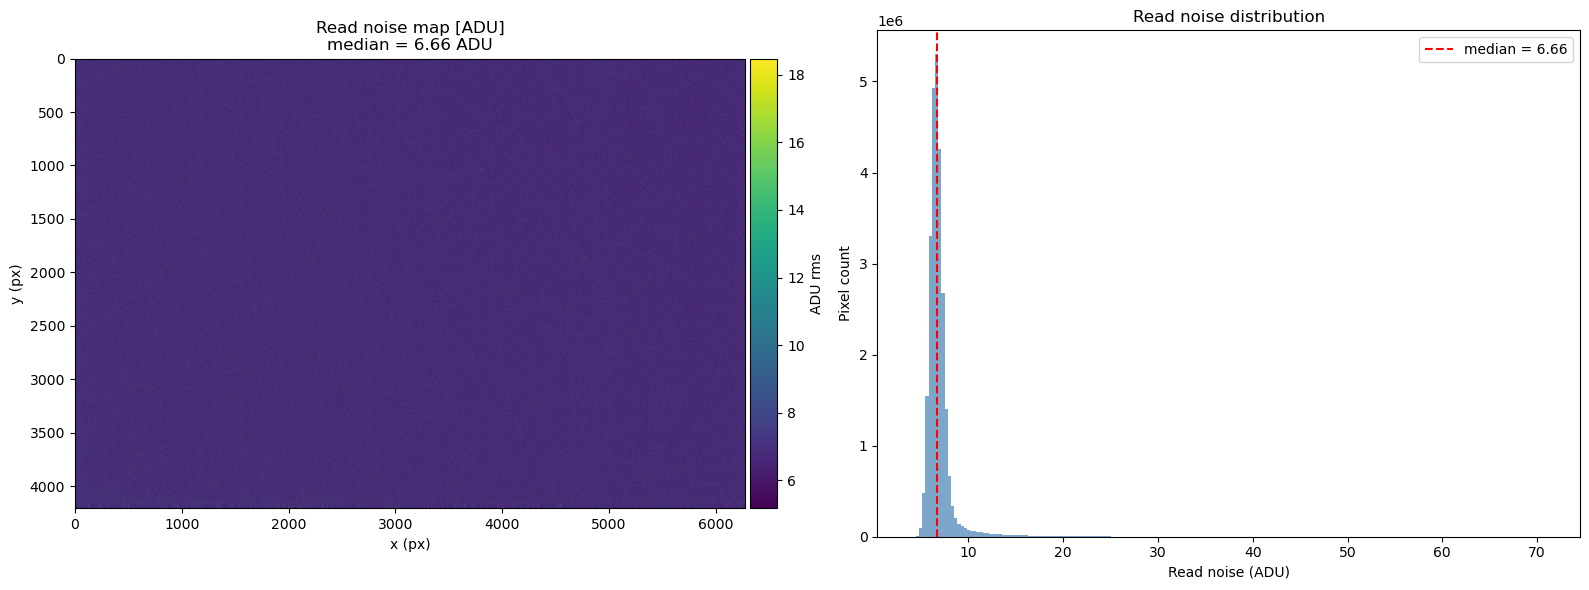

In [19]:
fig = plt.figure(figsize=(16, 6))
ct.noise_map_with_histogram(fig, read_noise_map_adu, label='Read noise', unit='ADU')
plt.savefig('tmpimg/0717_read_noise_map.png', dpi=dpi, bbox_inches='tight')
plt.show()

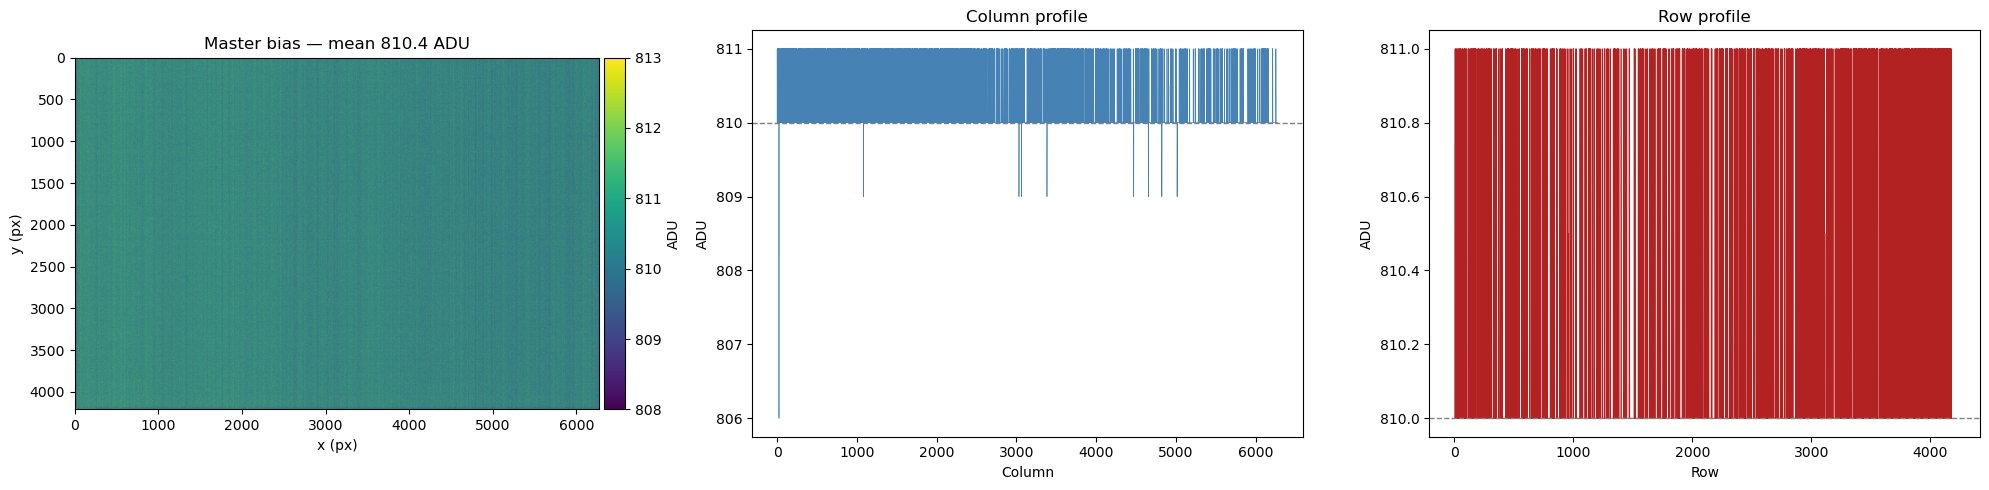

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
ct.image_with_colorbar(axes[0], master_bias, label='ADU', percentile_clip=(1, 99))
axes[0].set_title(f'Master bias — mean {master_bias.mean():.1f} ADU')
axes[1].plot(np.median(master_bias, axis=0), lw=0.5, color='steelblue')
axes[1].axhline(np.median(master_bias), ls='--', color='gray', lw=1)
axes[1].set_xlabel('Column'); axes[1].set_ylabel('ADU'); axes[1].set_title('Column profile')
axes[2].plot(np.median(master_bias, axis=1), lw=0.5, color='firebrick')
axes[2].axhline(np.median(master_bias), ls='--', color='gray', lw=1)
axes[2].set_xlabel('Row'); axes[2].set_ylabel('ADU'); axes[2].set_title('Row profile')
plt.tight_layout(); plt.savefig('tmpimg/0717_bias_structure.png', dpi=dpi, bbox_inches='tight'); plt.show()

## Bias temporal stability

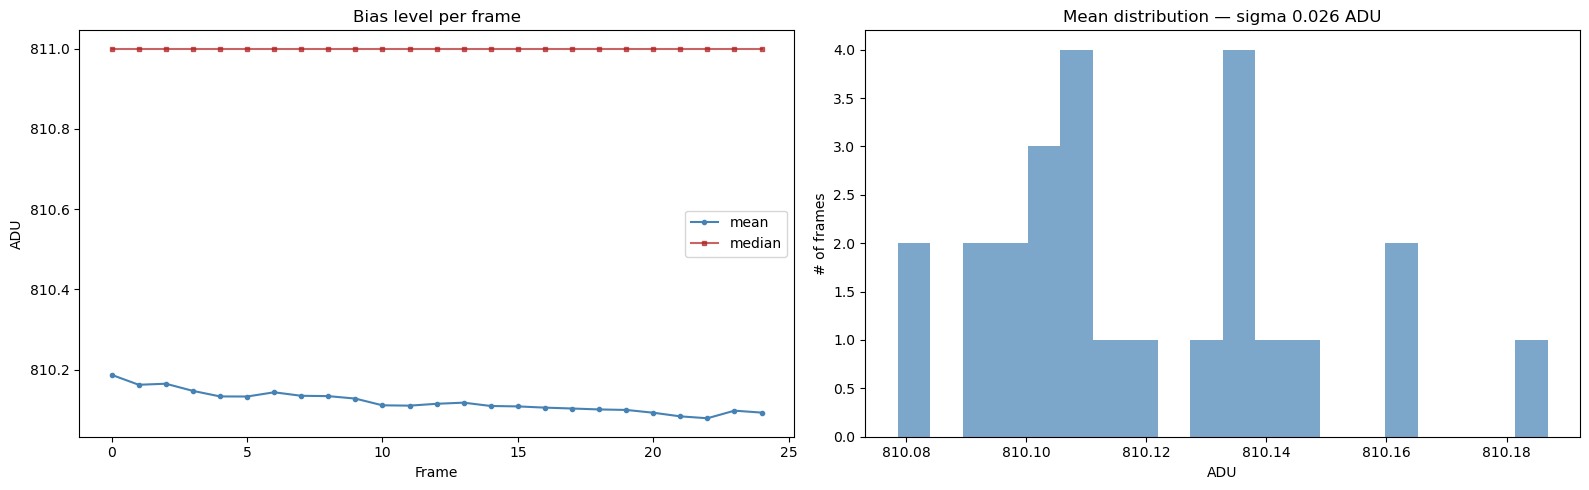

bias mean range 810.08 - 810.19 ADU, sigma 0.0262, MAD-sigma 0.0270


In [21]:
fmean = np.array([float(np.mean(ct.load_frame(f))) for f in main_bias_files])
fmed  = np.array([float(np.median(ct.load_frame(f))) for f in main_bias_files])
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(fmean, 'o-', ms=3, color='steelblue', label='mean')
axes[0].plot(fmed, 's-', ms=3, color='firebrick', alpha=0.7, label='median')
axes[0].set_xlabel('Frame'); axes[0].set_ylabel('ADU'); axes[0].set_title('Bias level per frame'); axes[0].legend()
axes[1].hist(fmean, bins=20, color='steelblue', alpha=0.7)
axes[1].set_xlabel('ADU'); axes[1].set_ylabel('# of frames')
axes[1].set_title(f'Mean distribution — sigma {np.std(fmean):.3f} ADU')
plt.tight_layout(); plt.savefig('tmpimg/0709_bias_stability.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'bias mean range {fmean.min():.2f} - {fmean.max():.2f} ADU, sigma {np.std(fmean):.4f}, MAD-sigma {ct.mad_sigma(fmean):.4f}')

# 3. Bias / Dark offset structure

In [22]:
b0 = ct.load_frame(darkcal_files[-14][('BIAS', 0.0)][-1], roi=roi)
print("min      max      mean      std")
print(f"{b0.min():<8.1f} {b0.max():<8.1f} {b0.mean():<8.3f} {b0.std():<8.3f}")
print("0.1,   1,   5,   10,  25,  50,  75,  90,  95,  99,  99.9   percentiles")
print(np.percentile(b0, [0.1, 1, 5, 10, 25, 50, 75, 90, 95, 99, 99.9]))


min      max      mean      std
700.0    939.0    810.609  7.168   
0.1,   1,   5,   10,  25,  50,  75,  90,  95,  99,  99.9   percentiles
[780. 794. 799. 802. 806. 811. 815. 819. 822. 827. 845.]


In [23]:
d0 = ct.load_frame(darkcal_files[-14][('DARK', 5.0)][-1], roi=roi)
print("min      max      mean      std")
print(f"{d0.min():<8.1f} {d0.max():<8.1f} {d0.mean():<8.3f} {d0.std():<8.3f}")
print("0.1,   1,   5,   10,  25,  50,  75,  90,  95,  99,  99.9   percentiles")
print(np.percentile(d0, [0.1, 1, 5, 10, 25, 50, 75, 90, 95, 99, 99.9]))


min      max      mean      std
697.0    34313.0  810.646  12.638  
0.1,   1,   5,   10,  25,  50,  75,  90,  95,  99,  99.9   percentiles
[780. 794. 799. 802. 806. 811. 815. 819. 822. 827. 846.]


# 4. Dark Current

In [24]:
"""
LONG RUNTIME CELL, ETA: 1 Frame = 1 second, i.e. 60 frames ~= 1 min
"""
dark_current_vs_temp_results, dark_current_vs_exposure_results = ct.dark_current_vs_temperature(
    darkcal_files, gain=gain, roi=roi,
    arrhenius_fit=True, current_vs_exposure=True)

md = dark_current_vs_temp_results.metadata
ss = dark_current_vs_temp_results.scalar_summary

temps = md["temperatures_c"]
dark_rates = md["dark_rates_e_per_s"]
dark_rate_errors = md["dark_rate_errors_e_per_s"]

if md["fit_success"]:
    print("Success and Arrhenius fit successful.")
    A = ss["arrhenius_A"]
    Ea = ss["arrhenius_Ea_eV"]
    A_err = ss["arrhenius_A_err"]
    Ea_err = ss["arrhenius_Ea_err_eV"]
else:
    print("Success but Arrhenius fit failed.")

Success and Arrhenius fit successful.


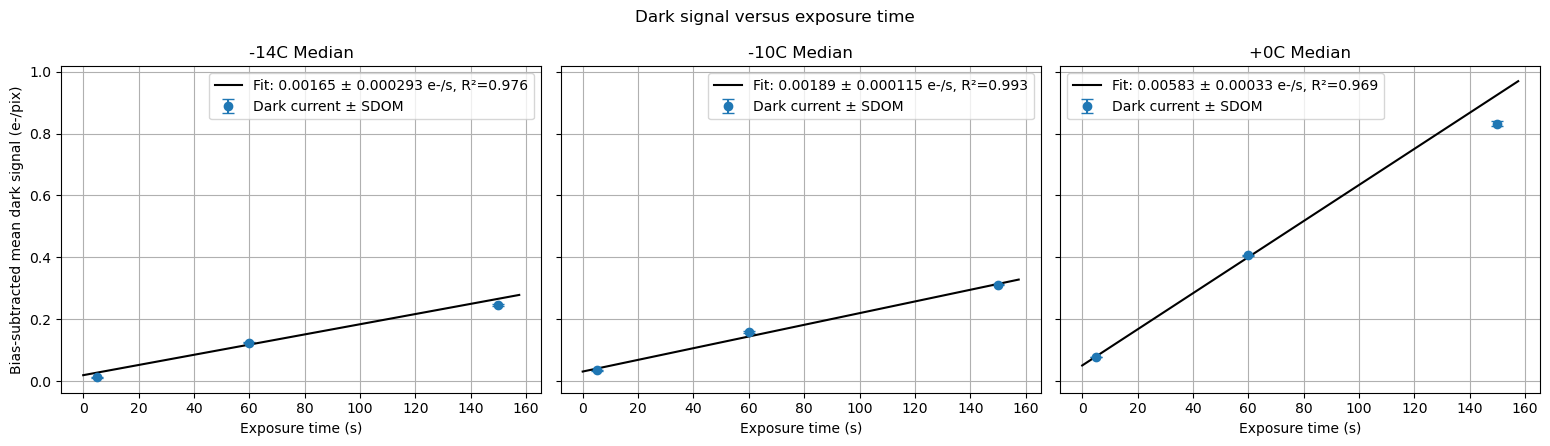

In [25]:
fig, axes = plt.subplots(1, len(dark_current_vs_exposure_results), figsize=(5.2 * len(dark_current_vs_exposure_results), 4.5), sharey=True)

for ax, (i, result) in zip(np.atleast_1d(axes), enumerate(dark_current_vs_exposure_results)):
    ct.dark_current_vs_exposure_plot(ax, result)
    ax.set_title(f"{temps[i]:+.0f}C Median")

axes[0].set_ylabel("Bias-subtracted mean dark signal (e-/pix)")

fig.suptitle("Dark signal versus exposure time")
plt.tight_layout()
plt.savefig("tmpimg/0717_dark_vs_exposure.png", dpi=dpi); plt.show()

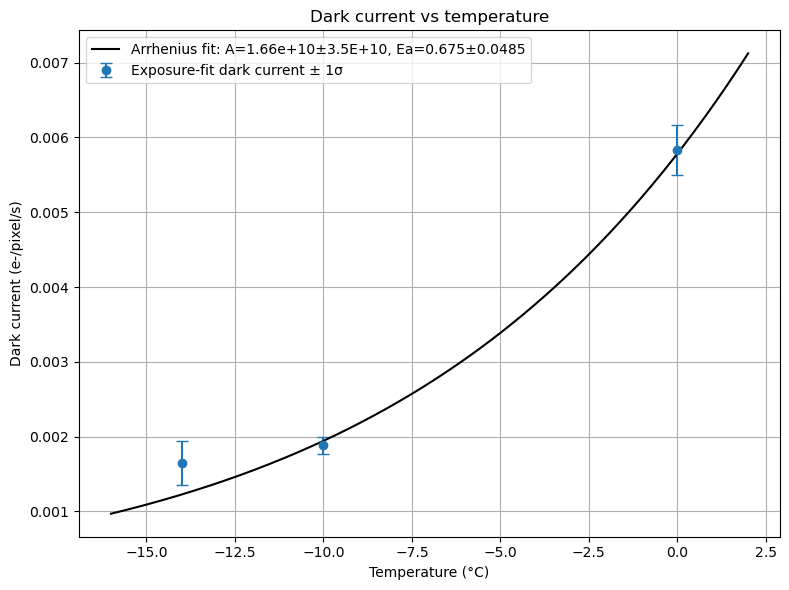

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
ct.dark_current_vs_temperature_plot(ax, dark_current_vs_temp_results, arrhenius_fit=md["fit_success"])
plt.tight_layout()
plt.savefig("tmpimg/0717_dark_vs_temperature.png", dpi=dpi); plt.show()